In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Define the State
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    result: str

# 2. Define the Nodes (Functions)
def show_equation(state: QuadState):
    a, b, c = state['a'], state['b'], state['c']
    equation = f"{a}x² + ({b})x + ({c}) = 0"
    return {"equation": equation}

def calculate_discriminant(state: QuadState):
    a, b, c = state['a'], state['b'], state['c']
    d = (b**2) - (4 * a * c)
    return {"discriminant": d}

def real_roots(state: QuadState):
    a, b, d = state['a'], state['b'], state['discriminant']
    root1 = (-b + (d**0.5)) / (2 * a)
    root2 = (-b - (d**0.5)) / (2 * a)
    return {"result": f"Two distinct real roots: {root1} and {root2}"}

def repeated_roots(state: QuadState):
    a, b = state['a'], state['b']
    root = -b / (2 * a)
    return {"result": f"One repeated real root: {root}"}

def no_real_roots(state: QuadState):
    return {"result": "No real roots (Imaginary roots)"}

# 3. Define the Routing Logic
def check_condition(state: QuadState):
    d = state['discriminant']
    if d > 0:
        return "real_roots"
    elif d == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

# 4. Build the Graph
builder = StateGraph(QuadState)

builder.add_node("show_equation", show_equation)
builder.add_node("calculate_discriminant", calculate_discriminant)
builder.add_node("real_roots", real_roots)
builder.add_node("repeated_roots", repeated_roots)
builder.add_node("no_real_roots", no_real_roots)

builder.add_edge(START, "show_equation")
builder.add_edge("show_equation", "calculate_discriminant")

# Adding Conditional Edges
builder.add_conditional_edges("calculate_discriminant",check_condition)

builder.add_edge("real_roots", END)
builder.add_edge("repeated_roots", END)
builder.add_edge("no_real_roots", END)

graph = builder.compile()

# Invoke the workflow
inputs = {"a": 1, "b": -5, "c": 6}
print(graph.invoke(inputs)['result'])

Two distinct real roots: 3.0 and 2.0


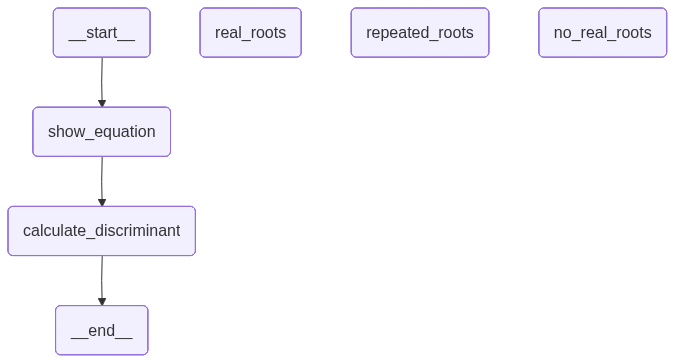

In [17]:
graph

In [19]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

load_dotenv()

# Structured Output Schemas (Pydantic)
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UI", "Performance", "Bug", "Support", "Other"]
    tone: str
    urgency: Literal["Low", "Medium", "High"]

# State definition
class ReviewState(TypedDict):
    review: str
    sentiment: str
    diagnosis: dict
    response: str

# Kimi k2.6 via OpenAI-compatible API
llm = ChatOpenAI(
    model="kimi-k2.6",
    base_url="https://api.moonshot.ai/v1",
  
    api_key = 'sk-moX8fkbUBOpZW4c0Gjz0dG4GIqzOrvynPbiOMs5bg6oLvscY'
)

# Nodes
def find_sentiment(state: ReviewState):
    structured_llm = llm.with_structured_output(SentimentSchema)
    res = structured_llm.invoke(f"Determine the sentiment: {state['review']}")
    return {"sentiment": res.sentiment}

def positive_response(state: ReviewState):
    res = llm.invoke(f"Write a warm thank you reply for this review: {state['review']}")
    return {"response": res.content}

def run_diagnosis(state: ReviewState):
    structured_llm = llm.with_structured_output(DiagnosisSchema)
    res = structured_llm.invoke(f"Diagnose this negative review: {state['review']}")
    return {"diagnosis": res.model_dump()}

def negative_response(state: ReviewState):
    diag = state['diagnosis']
    prompt = f"The user has a {diag['issue_type']} issue. Their tone is {diag['tone']} and urgency is {diag['urgency']}. Write an empathetic reply."
    res = llm.invoke(prompt)
    return {"response": res.content}

# Conditional Router
def check_sentiment(state: ReviewState):
    if state['sentiment'] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

# Graph Construction
workflow = StateGraph(ReviewState)

workflow.add_node("find_sentiment", find_sentiment)
workflow.add_node("positive_response", positive_response)
workflow.add_node("run_diagnosis", run_diagnosis)
workflow.add_node("negative_response", negative_response)

workflow.add_edge(START, "find_sentiment")
workflow.add_conditional_edges("find_sentiment", check_sentiment)
workflow.add_edge("positive_response", END)
workflow.add_edge("run_diagnosis", "negative_response")
workflow.add_edge("negative_response", END)

app = workflow.compile()

# Test with a negative review
test_input = {"review": "The app keeps freezing on the login screen. This is unacceptable!"}
result = app.invoke(test_input)
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")

python-dotenv could not parse statement starting at line 4


Sentiment: negative
Response: Subject: Re: [Bug Description] — Escalated & Actively Being Fixed

Hi [Name],

I’m truly sorry. You shouldn’t have to deal with this, and I completely understand why this is unacceptable—especially when it’s blocking your work right now.

**Here is exactly what I’m doing this minute:**
*   I’ve escalated this to our engineering team as a **P0/critical incident** and flagged your account for immediate priority.
*   A senior engineer is actively investigating the root cause as we speak.
*   I am personally monitoring this case and will update you within the next **30 minutes**, even if the fix is still in progress.

I am not going to leave you in the dark. If this is halting critical operations, please reply to this email or call/text me directly at **[your direct number]**. I will answer.

You have my word that I will own this until it’s fully resolved.

I’ll be back in touch shortly.

Best,  
[Your Name]  
[Your Title]  
[Direct Phone] | [Direct Email]


In [20]:
class SentimentSchema(BaseModel):
    sentiment:Literal['positive','negative'] = Field(description='Sentiment of the review')
    


In [27]:
model = ChatOpenAI(
    model="kimi-k2.6",
    base_url="https://api.moonshot.ai/v1",
  
    api_key = 'sk-moX8fkbUBOpZW4c0Gjz0dG4GIqzOrvynPbiOMs5bg6oLvscY'
)

In [28]:
structure_model = model.with_structured_output(SentimentSchema)

In [30]:
structure_model.invoke("you are a good teacher").sentiment

'positive'

In [31]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis: dict
    response: str



In [61]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UI", "Performance", "Bug", "Support", "Other"]
    tone: str
    urgency: Literal["Low", "Medium", "High"]

In [66]:
structured_model1 = model.with_structured_output(SentimentSchema)
structure_model2 = model.with_structured_output(DiagnosisSchema)

In [70]:
def find_sentiment(state : ReviewState):
    prompt=f" by reading the {state['review']} you need to determine the sentiment "
    sentiment = structured_model1.invoke(prompt).sentiment #structured_model1 ke andar hai sentiment object
    return {'sentiment': sentiment}


def check_sentiment(state : ReviewState) -> Literal["positive_response","run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState):
    prompt = (
        f"Write a warm thank-you message in response to this review: {state['review']}. "
        "Also ask the user to give feedback."
    )
    response = model.invoke(prompt).content
    return {'response': response}


def run_diagnosis(state: ReviewState):
    prompt = f'diagnose this negative review: {state['review']}'
    response = structure_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):
    diag = state['diagnosis']
    prompt = (
        f"you are a support assistant. The user has a {diag['issue_type']}, "
        f"the urgency level is {diag['urgency']} and the tone is {diag['tone']}"
    )
    response = model.invoke(prompt).content
    return {'response': response}

In [71]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)
graph.add_node('run_diagnosis',run_diagnosis)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
workflow = graph.compile()

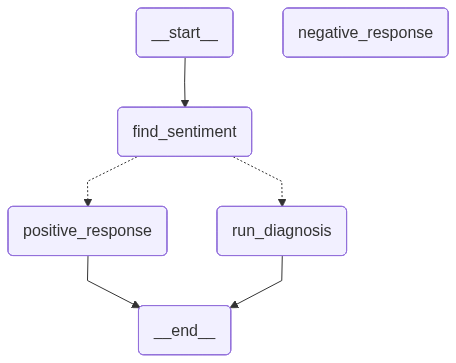

In [64]:
workflow

In [72]:

initial_state = {'review': f'the food was very bad it costed me food poisning'}

final_state = workflow.invoke(initial_state)



In [73]:
print(final_state)

{'review': 'the food was very bad it costed me food poisning', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Support', 'tone': 'Negative', 'urgency': 'High'}, 'response': "I sincerely apologize that you're dealing with this, and I completely understand your frustration. A high-priority issue like this deserves immediate attention, and I'm treating it as such right now.\n\nPlease tell me exactly what is happening, including any error messages, account details, or recent changes involved. I will prioritize getting this resolved for you immediately—no runaround, no delays. If this requires escalation to our specialist team, I will initiate that the moment we finish here.\n\nWhat specific issue are you experiencing?"}
